In [26]:
import Util.ExploratoryDataAnalysis
import Util.ModelDevelopment
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

In [2]:
data_dir = Path("data")

dfs = [
    Util.ExploratoryDataAnalysis.load_battles_file_to_df(file)
    for file in data_dir.glob("*.json")
]

df = pd.concat(dfs, ignore_index=True)

df = pd.get_dummies(df, columns=['result'])

print(df.shape)
df.head()

(430591, 28)


,battleTime,gameModeId,playerTag,opponentTag,playerCrowns,opponentCrowns,crown_diff,p_card_1,o_card_1,p_card_2,...,o_card_6,p_card_7,o_card_7,p_card_8,o_card_8,p_card_9,o_card_9,result_draw,result_loss,result_win
0,20260303T044817.000Z,72000006,#9CVVPULRY,#9RRRV9PLP,1,0,1,26000007,26000017,26000011,...,26000004,26000021,26000043,28000007,28000011,159000000,159000000,0,0,1
1,20260303T040122.000Z,72000006,#9CVVPULRY,#2200YRUGGU,3,0,3,26000007,27000013,26000011,...,28000026,26000021,28000013,28000007,26000101,159000000,159000000,0,0,1
2,20260303T035814.000Z,72000006,#9CVVPULRY,#VYGPRCQLJ,0,1,-1,26000007,26000011,26000011,...,28000004,26000021,26000021,28000007,28000001,159000000,159000000,0,1,0
3,20260303T034754.000Z,72000006,#9CVVPULRY,#2LRLG2C28,1,0,1,26000007,26000064,26000011,...,26000048,26000021,28000003,28000007,26000042,159000000,159000000,0,0,1
4,20260303T034441.000Z,72000006,#9CVVPULRY,#8UJQQCQR,1,0,1,26000007,26000007,26000011,...,28000015,26000021,26000005,28000007,26000044,159000000,159000000,0,0,1


In [3]:
# Get the list of all the cards in the game from Clash Royale API
cards_df = Util.ExploratoryDataAnalysis.fetch_all_cards()

display(cards_df)

,name,id,maxLevel,maxEvolutionLevel,elixirCost,rarity,is_support
0,Knight,26000000,16,3.0,3.0,common,False
1,Archers,26000001,16,1.0,3.0,common,False
2,Goblins,26000002,16,2.0,2.0,common,False
3,Giant,26000003,14,2.0,5.0,rare,False
4,P.E.K.K.A,26000004,11,1.0,7.0,epic,False
...,...,...,...,...,...,...,...
120,Vines,28000026,11,NaN,3.0,epic,False
121,Tower Princess,159000000,16,NaN,NaN,common,True
122,Cannoneer,159000001,11,NaN,NaN,epic,True
123,Dagger Duchess,159000002,8,NaN,NaN,legendary,True


In [4]:
X, y, artifacts = Util.ModelDevelopment.build_features_and_target(df, cards_df, n_cards_per_side=9, return_artifacts=True)

print(X.shape)
X.head()

(430591, 267)


,gameModeId,hour,day_of_week,p_has_26000000,p_has_26000001,p_has_26000002,p_has_26000003,p_has_26000004,p_has_26000005,p_has_26000006,...,p_building_count,o_avg_elixir,o_total_elixir,o_troop_count,o_spell_count,o_building_count,avg_elixir_diff,spell_diff,building_diff,troop_diff
0,72000006,4,1,0,0,0,0,0,0,0,...,1,4.714286,33.0,5,3,0,-1.339286,-1,1,0
1,72000006,4,1,0,0,0,0,0,0,0,...,1,4.000000,32.0,4,2,2,-0.625000,0,-1,1
2,72000006,3,1,0,0,0,0,0,0,0,...,1,3.125000,25.0,6,2,0,0.250000,0,1,-1
3,72000006,3,1,0,0,0,0,0,0,0,...,1,4.750000,38.0,7,1,0,-1.375000,1,1,-2
4,72000006,3,1,0,0,0,0,0,0,0,...,1,4.000000,32.0,7,1,0,-0.625000,1,1,-2


In [15]:
# Split: train / val / test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", np.shape(y_train))
print("X_val:", X_val.shape, "y_val:", np.shape(y_val))
print("X_test:", X_test.shape, "y_test:", np.shape(y_test))

Shapes:
X_train: (275577, 267) y_train: (275577,)
X_val: (68895, 267) y_val: (68895,)
X_test: (86119, 267) y_test: (86119,)


In [20]:
def eval_binary_proba(y_true, p_pred, eps=1e-15):
    """
    y_true: {0,1}
    p_pred: predicted probability for class 1
    """
    p = np.clip(p_pred, eps, 1 - eps)
    return {
        "logloss": float(log_loss(y_true, p)),
        "brier": float(brier_score_loss(y_true, p)),
        "roc_auc": float(roc_auc_score(y_true, p)),
        "p_mean": float(np.mean(p)),
        "p_std": float(np.std(p)),
    }

def make_xgb_base_params(scale_pos_weight=1.0):
    return dict(
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="logloss",
        n_estimators=5000,
        learning_rate=0.02,          # slightly lower than 0.03 often helps prob quality
        max_depth=5,
        min_child_weight=10,
        gamma=0.5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=0.0,
        max_delta_step=0,            # try 1 or 5 if probs are extreme/unstable
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
    )

In [23]:
pos = np.sum(y_train == 1)
neg = np.sum(y_train == 0)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

base_params = make_xgb_base_params(scale_pos_weight)

baseline = XGBClassifier(
    **base_params,
    early_stopping_rounds=200
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

p_val = baseline.predict_proba(X_val)[:, 1]
p_test = baseline.predict_proba(X_test)[:, 1]

baseline_val_metrics = eval_binary_proba(y_val, p_val)
baseline_test_metrics = eval_binary_proba(y_test, p_test)

baseline_val_metrics, baseline_test_metrics, baseline.best_iteration

({'logloss': 0.6705592369465246,
  'brier': 0.23932186763343666,
  'roc_auc': 0.612424210107827,
  'p_mean': 0.502944827079773,
  'p_std': 0.09770844131708145},
 {'logloss': 0.6717130790494149,
  'brier': 0.239841500141842,
  'roc_auc': 0.6086623870190779,
  'p_mean': 0.5030831694602966,
  'p_std': 0.09674403071403503},
 4998)

In [24]:
from math import isnan

def combined_score(metrics, w_logloss=0.45, w_brier=0.45, w_auc=0.10):
    # lower is better
    return (
        w_logloss * metrics["logloss"] +
        w_brier  * metrics["brier"] +
        w_auc    * (1.0 - metrics["roc_auc"])
    )

def run_param_search(
    X_train, y_train, X_val, y_val, X_test, y_test,
    base_params,
    param_distributions,
    n_trials=30,
    early_stopping_rounds=200,
    random_state=42,
    verbose_every=5
):
    sampler = ParameterSampler(param_distributions, n_iter=n_trials, random_state=random_state)
    results = []
    best = None

    for i, sampled in enumerate(sampler, start=1):
        params = dict(base_params)
        params.update(sampled)

        model = XGBClassifier(
            **params,
            early_stopping_rounds=early_stopping_rounds
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        p_val = model.predict_proba(X_val)[:, 1]
        p_test = model.predict_proba(X_test)[:, 1]

        m_val = eval_binary_proba(y_val, p_val)
        m_test = eval_binary_proba(y_test, p_test)

        row = {
            "trial": i,
            "best_iteration": int(getattr(model, "best_iteration", -1) if getattr(model, "best_iteration", None) is not None else -1),
            "val_score": combined_score(m_val),
            **{f"val_{k}": v for k, v in m_val.items()},
            **{f"test_{k}": v for k, v in m_test.items()},
            **sampled
        }
        results.append(row)

        if (best is None) or (row["val_score"] < best["val_score"]):
            best = row

        if verbose_every and (i % verbose_every == 0 or i == 1):
            print(
                f"[{i:>3}/{n_trials}] val_score={row['val_score']:.6f} "
                f"val_logloss={row['val_logloss']:.5f} val_brier={row['val_brier']:.5f} val_auc={row['val_roc_auc']:.5f} "
                f"(best val_score={best['val_score']:.6f})"
            )

    df = pd.DataFrame(results).sort_values("val_score", ascending=True).reset_index(drop=True)
    return df, best

param_distributions = {
    # core structure
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 5, 10, 20, 40],

    # regularization
    "reg_lambda": [1.0, 2.0, 5.0, 10.0, 20.0],
    "reg_alpha": [0.0, 1e-3, 1e-2, 1e-1, 1.0],
    "gamma": [0.0, 0.1, 0.3, 0.5, 1.0],

    # sampling
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],

    # learning dynamics
    "learning_rate": [0.01, 0.02, 0.03, 0.05],

    # stability (try enabling if you see very extreme probabilities)
    "max_delta_step": [0, 1, 5],
}

In [29]:
N_TRIALS = 20  # increase if you can
search_df, best_row = run_param_search(
    X_train, y_train, X_val, y_val, X_test, y_test,
    base_params=base_params,
    param_distributions=param_distributions,
    n_trials=N_TRIALS,
    early_stopping_rounds=200,
    random_state=42,
    verbose_every=1
)

search_df.head(10)

[  1/20] val_score=0.449788 val_logloss=0.67231 val_brier=0.24015 val_auc=0.60820 (best val_score=0.449788)
[  2/20] val_score=0.450001 val_logloss=0.67253 val_brier=0.24024 val_auc=0.60745 (best val_score=0.449788)
[  3/20] val_score=0.447208 val_logloss=0.66942 val_brier=0.23878 val_auc=0.61481 (best val_score=0.447208)
[  4/20] val_score=0.453494 val_logloss=0.67616 val_brier=0.24199 val_auc=0.59674 (best val_score=0.447208)
[  5/20] val_score=0.447803 val_logloss=0.67016 val_brier=0.23912 val_auc=0.61372 (best val_score=0.447208)
[  6/20] val_score=0.448241 val_logloss=0.67059 val_brier=0.23933 val_auc=0.61220 (best val_score=0.447208)
[  7/20] val_score=0.452107 val_logloss=0.67470 val_brier=0.24130 val_auc=0.60093 (best val_score=0.447208)
[  8/20] val_score=0.447198 val_logloss=0.66944 val_brier=0.23878 val_auc=0.61502 (best val_score=0.447198)
[  9/20] val_score=0.448325 val_logloss=0.67064 val_brier=0.23936 val_auc=0.61177 (best val_score=0.447198)
[ 10/20] val_score=0.447403 

,trial,best_iteration,val_score,val_logloss,val_brier,val_roc_auc,val_p_mean,val_p_std,test_logloss,test_brier,...,test_p_std,subsample,reg_lambda,reg_alpha,min_child_weight,max_depth,max_delta_step,learning_rate,gamma,colsample_bytree
0,8,4926,0.447198,0.669443,0.238779,0.615017,0.504272,0.108936,0.671171,0.239578,...,0.107945,0.6,2.0,0.010,10,6,1,0.02,1.0,1.0
1,3,4963,0.447208,0.669420,0.238777,0.614807,0.504534,0.105663,0.671141,0.239583,...,0.104631,0.8,2.0,0.010,1,6,1,0.02,1.0,0.6
2,10,3939,0.447403,0.669665,0.238890,0.614465,0.504087,0.108458,0.671261,0.239626,...,0.107547,0.8,5.0,0.100,20,6,0,0.03,1.0,0.6
3,12,2516,0.447774,0.670074,0.239090,0.613503,0.503563,0.107026,0.671579,0.239773,...,0.106244,0.9,20.0,1.000,40,6,1,0.05,0.3,0.6
4,5,4968,0.447803,0.670162,0.239117,0.613724,0.503552,0.106540,0.671557,0.239771,...,0.105438,0.9,1.0,0.010,20,5,1,0.03,0.5,0.7
5,11,4982,0.447940,0.670256,0.239175,0.613039,0.503220,0.098803,0.671975,0.239973,...,0.097792,0.6,2.0,0.010,5,5,1,0.02,0.3,0.9
6,20,4417,0.447959,0.670268,0.239178,0.612921,0.503411,0.107090,0.672251,0.240082,...,0.106050,0.6,10.0,0.010,5,4,5,0.05,0.5,1.0
7,14,4999,0.448148,0.670448,0.239272,0.612254,0.503112,0.097506,0.671985,0.239987,...,0.096546,0.6,5.0,0.100,1,5,1,0.02,0.1,0.7
8,6,4999,0.448241,0.670586,0.239329,0.612203,0.502946,0.097724,0.671810,0.239878,...,0.096837,0.8,10.0,0.001,20,5,5,0.02,0.1,1.0
9,9,2294,0.448325,0.670644,0.239359,0.611767,0.503768,0.108023,0.672477,0.240195,...,0.107411,0.7,5.0,0.000,40,6,0,0.05,0.1,0.6


In [47]:
# Extract best hyperparams
best_hparams = {k: best_row[k] for k in param_distributions.keys()}

# Create an early-stopping split from the full training data
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

final_params = dict(base_params)
final_params.update(best_hparams)

final_model = XGBClassifier(
    **final_params,
    early_stopping_rounds=300
)

final_model.fit(
    X_train2, y_train2,
    eval_set=[(X_val2, y_val2)],
    verbose=False
)

p_test_final = final_model.predict_proba(X_test)[:, 1]
final_test_metrics = eval_binary_proba(y_test, p_test_final)

final_model.best_iteration, final_test_metrics

(4543,
 {'logloss': 0.6707291893022478,
  'brier': 0.23937503436835725,
  'roc_auc': 0.6110031929810816,
  'p_mean': 0.5039240717887878,
  'p_std': 0.10510808229446411})

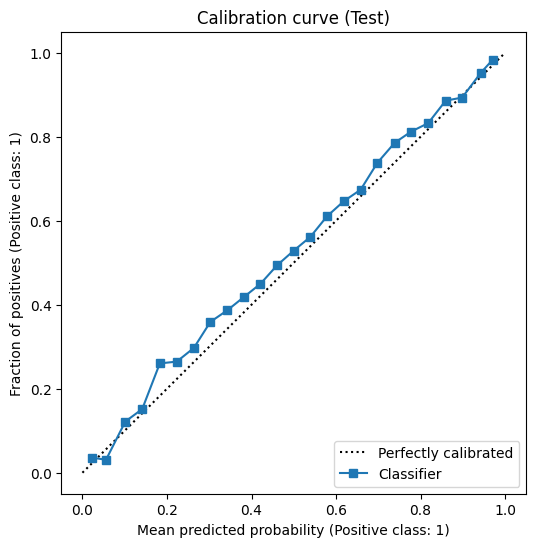

In [48]:
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(
    y_test,
    p_test_final,
    n_bins=25,
    strategy="uniform",
    ax=ax
)
ax.set_title("Calibration curve (Test)")
plt.show()

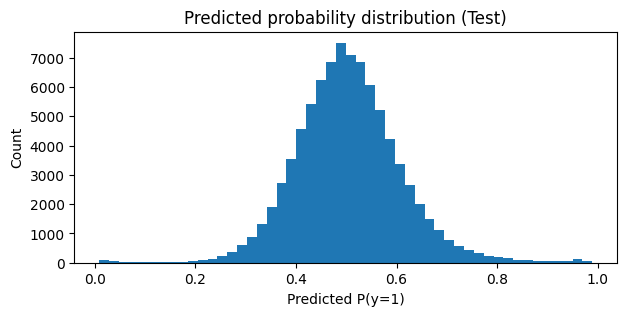

In [49]:
plt.figure(figsize=(7, 3))
plt.hist(p_test_final, bins=50)
plt.title("Predicted probability distribution (Test)")
plt.xlabel("Predicted P(y=1)")
plt.ylabel("Count")
plt.show()

In [53]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator=final_model,
    method="sigmoid",   # try "isotonic" too (often great with big data)
    cv="prefit"
)

calibrated_model.fit(X_val, y_val)

CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=1.0,
                                               device=None,
                                               early_stopping_rounds=300,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=1.0,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.02, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=1, max_depth=6,
                                               max_leaves=None,
                                               min_child_weight=10, missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=5000, n_jobs=-1,
                                               num_parallel_tree=None, ...))

Calibrated Test Log Loss: 0.6717149307556638
Calibrated Test Brier: 0.23972150119557784
Calibrated Test ROC AUC: 0.6110031954194951


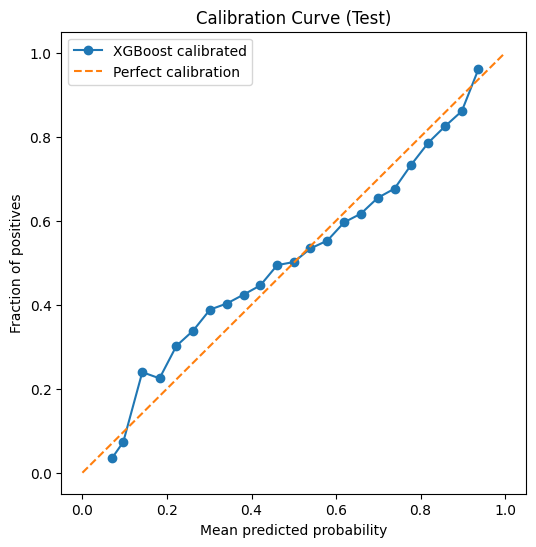

In [54]:
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

p_test = calibrated_model.predict_proba(X_test)[:, 1]

print("Calibrated Test Log Loss:", log_loss(y_test, p_test))
print("Calibrated Test Brier:", brier_score_loss(y_test, p_test))
print("Calibrated Test ROC AUC:", roc_auc_score(y_test, p_test))

prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=25, strategy="uniform")

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost calibrated")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve (Test)")
plt.legend()
plt.show()